# <font color="purple"><h3 align="center">Exploratory Data Analysis (EDA)</h3></font>

# <font color='red'>Titanic </font>

## <font color='red'>About the Data</font>

This dataset contains details of passengers who traveled on the Titanic ship.


## Attributes 

1. PassengerId - Unique id for each passenger
2. Survived - Survival status (0 = No, 1 = Yes)
3. Pclass - Ticket class (1 = upper, 2 = middle, 3 = lower)
4. Name - Passenger Name
5. Sex - Gender of the passenger
6. Age - Age in years
7. Sibsp - No of Siblings/spouses aboard
8. parch - No of parents/childern aboard
9. Ticket - Ticket Number
10. Fare - Ticket price paid
11. Cabin - Cabin Number
12. Embarked - port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

## <font color='red'>Step of EDA Process</font>

1. Understanding the data
2. Data loading & Initial Inspection
3. Data Cleaning
   - Handle missing values
   - Fix data types
   - Remove duplicates
4. Outlier detection
5. Univariate Analysis
6. Bivariate Analysis
7. Multi Variate Analysis
8. Correlation Analysis

## <font color='red'>1. Understanding the data</font>

1. PassengerId - Unique id for each passenger
2. Survived - Survival status (0 = No, 1 = Yes)
3. Pclass - Ticket class (1 = upper, 2 = middle, 3 = lower)
4. Name - Passenger Name
5. Sex - Gender of the passenger
6. Age - Age in years
7. Sibsp - No of Siblings/spouses aboard
8. parch - No of parents/childern aboard
9. Ticket - Ticket Number
10. Fare - Ticket price paid
11. Cabin - Cabin Number
12. Embarked - port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

## <font color='red'>2.1 Data Loading & Initial Inspection</font>

In [26]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

titanic = pd.read_csv("train.csv")

In [2]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic.shape

(891, 12)

In [5]:
list(titanic.columns)

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

## <font color='red'>3. Data Cleaning & Handling missing data</font>

In [16]:
titanic.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
titanic['Age'] = titanic.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

In [18]:
titanic['Deck'] = titanic['Cabin'].str[0]
titanic['Deck'] = titanic['Deck'].fillna('Unknown')

In [24]:
titanic.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Deck             0
dtype: int64

In [23]:
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])

In [25]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
 12  Deck         891 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB


## <font color='blue'>Report of Handling Missing Values</font>

During the data cleaning phase, missing values were identified in three main columns: Age, Cabin, and Embarked. Each column was handled based on its data type, importance, and the percentage of missing values.

## 1. Age Column 

- The Age column contained several missing values.
- Since Age is an important numerical feature that may influence survival, it could not be removed.
- Instead of filling with overall mean/median, a group-wise median imputation was performed based on Passenger Class (Pclass).
- This is because passengers in different classes tend to have different age distributions.

#### Method used:

- Missing Age values were replaced with the median age of passengers within the same Pclass.

## 2. Cabin Column

- The Cabin column had more than 75% missing values.
- The cabin numbers were highly unique and not useful directly for analysis.
- However, the first letter of the cabin number represents the deck, which is meaningful.
- A new feature called Deck was created by extracting the first letter.
- Missing values were labeled as 'Unknown'.

#### Method used:

- Cabin numbers were transformed into Deck categories, and missing values were marked as 'Unknown'.

## 3. Embarked Column

- The Embarked column had only 2 missing values.
- Since this is a categorical column, the safest method is to fill missing values with the mode (most frequent value).
- The most common boarding port was 'S' (Southampton).

#### Method used:

- Missing Embarked values were filled with the mode value 'S'.

## <font color='red'>4. Outlier Detection</font>

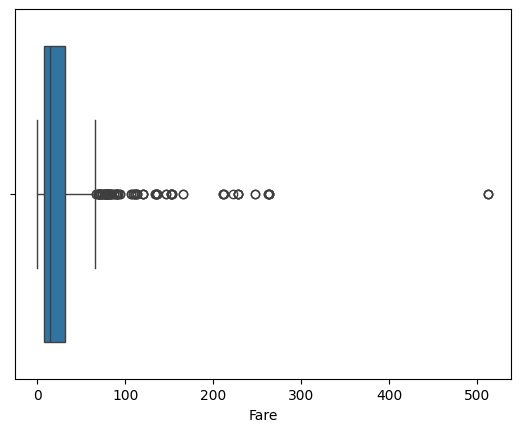

In [28]:
sns.boxplot(x = titanic['Fare'])

plt.show()

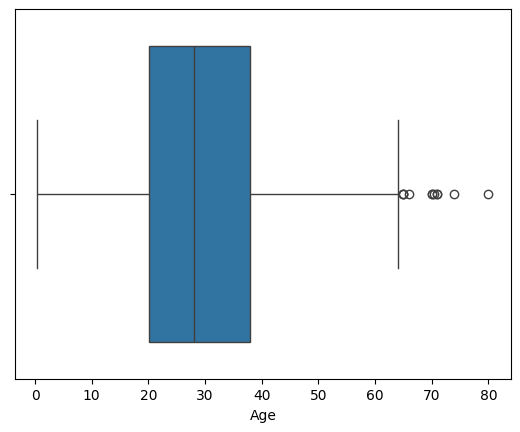

In [29]:
sns.boxplot(x = titanic['Age'])

plt.show()

## <font color='blue'>Insight Analysis</font>

- Fare reflects economic diversity: many passengers bought cheaper tickets, while a small group paid for luxury.
- Age reflects demographic diversity: the ship carried a mix of young, middle‑aged, and a few elderly passengers.
- Together, these plots show that Titanic passengers varied both in financial status and age profile
